In [1]:
import matplotlib.pyplot as plt
import torchvision
import numpy as np
from torchvision import transforms
import torch
from torchvision import datasets
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.optim as optim
import torch.nn.init as init

In [2]:
# Load CIFAR-100 without transform → images will be in PIL format
dataset = torchvision.datasets.CIFAR100(root='./data', train=True, download=True)
# CIFAR-100 class names
classes = torchvision.datasets.CIFAR100(root='./data', train=True).classes
print(classes)


['apple', 'aquarium_fish', 'baby', 'bear', 'beaver', 'bed', 'bee', 'beetle', 'bicycle', 'bottle', 'bowl', 'boy', 'bridge', 'bus', 'butterfly', 'camel', 'can', 'castle', 'caterpillar', 'cattle', 'chair', 'chimpanzee', 'clock', 'cloud', 'cockroach', 'couch', 'crab', 'crocodile', 'cup', 'dinosaur', 'dolphin', 'elephant', 'flatfish', 'forest', 'fox', 'girl', 'hamster', 'house', 'kangaroo', 'keyboard', 'lamp', 'lawn_mower', 'leopard', 'lion', 'lizard', 'lobster', 'man', 'maple_tree', 'motorcycle', 'mountain', 'mouse', 'mushroom', 'oak_tree', 'orange', 'orchid', 'otter', 'palm_tree', 'pear', 'pickup_truck', 'pine_tree', 'plain', 'plate', 'poppy', 'porcupine', 'possum', 'rabbit', 'raccoon', 'ray', 'road', 'rocket', 'rose', 'sea', 'seal', 'shark', 'shrew', 'skunk', 'skyscraper', 'snail', 'snake', 'spider', 'squirrel', 'streetcar', 'sunflower', 'sweet_pepper', 'table', 'tank', 'telephone', 'television', 'tiger', 'tractor', 'train', 'trout', 'tulip', 'turtle', 'wardrobe', 'whale', 'willow_tree',

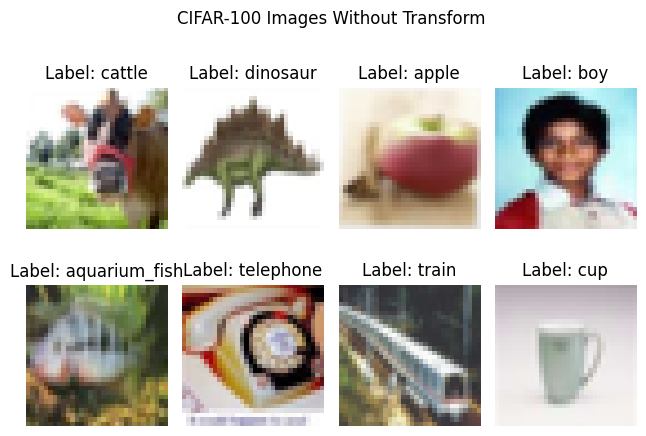

In [3]:
# Access the first 8 samples
for i in range(8):
    image, label = dataset[i]

    # Display image
    plt.subplot(2, 4, i+1)
    plt.imshow(image)
    plt.axis('off')
    plt.title(f"Label: {classes[label]}")

plt.suptitle("CIFAR-100 Images Without Transform")
plt.tight_layout()
plt.show()

In [8]:
image, label = dataset[i]

print(image)

<PIL.Image.Image image mode=RGB size=32x32 at 0x1C15345D360>


In [9]:
# 2. Transform: flatten the image to a vector
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)),  # normalize to [-1, 1]
])


# Load CIFAR-100 training dataset
train_dataset = datasets.CIFAR100(root='./data', train=True, download=True, transform=transform)

# Get length
print(f"Total training samples: {len(train_dataset)}")  # Output: 50000

# Similarly for test set
test_dataset = datasets.CIFAR100(root='./data', train=False, download=True, transform=transform)
print(f"Total test samples: {len(test_dataset)}")  # Output: 10000

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

Total training samples: 50000
Total test samples: 10000


In [27]:
# 4. Define a more dense ANN model
# 4. Define a more dense ANN model with Dropout
class DenseANN_LinearOnly(nn.Module):
    def __init__(self):
        super(DenseANN_LinearOnly, self).__init__()
        self.flatten = nn.Flatten()

        self.fc1 = nn.Linear(32*32*3, 1024)
        self.ac1 = nn.ReLU()
        self.fc2 = nn.Linear(1024, 512)
        self.ac2 = nn.ReLU()
        self.fc3 = nn.Linear(512, 100)  # 100 classes for CIFAR-100

    def forward(self, x):
        x = self.flatten(x)

        x = self.fc1(x)
        x = self.ac1(x)
        x = self.fc2(x)
        x = self.ac2(x)
        x = self.fc3(x)
        
        return x

# Instantiate and send to device
model = DenseANN_LinearOnly().to(device)


In [28]:
# 5. Loss and Optimizer with L2 Regularization
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.1)

In [29]:
# 6. Training loop with weight visualization

numEpoch = 10
for epoch in range(numEpoch):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    print(f"\nEpoch [{epoch+1}/{numEpoch}] Loss: {total_loss:.4f} Accuracy: {correct/total*100:.2f}%")


# 7. Test accuracy
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

print(f"\nFinal Test Accuracy: {correct / total * 100:.2f}%")




Epoch [1/10] Loss: 5873.2668 Accuracy: 12.85%

Epoch [2/10] Loss: 5178.5917 Accuracy: 20.66%

Epoch [3/10] Loss: 4822.3805 Accuracy: 24.73%

Epoch [4/10] Loss: 4542.5837 Accuracy: 27.73%

Epoch [5/10] Loss: 4272.9618 Accuracy: 30.87%

Epoch [6/10] Loss: 4012.5238 Accuracy: 34.52%

Epoch [7/10] Loss: 3754.2082 Accuracy: 37.92%

Epoch [8/10] Loss: 3496.4297 Accuracy: 41.56%

Epoch [9/10] Loss: 3245.2494 Accuracy: 45.12%

Epoch [10/10] Loss: 3006.4998 Accuracy: 48.58%

Final Test Accuracy: 24.21%


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.6313726..1.0].


torch.Size([3, 32, 32])


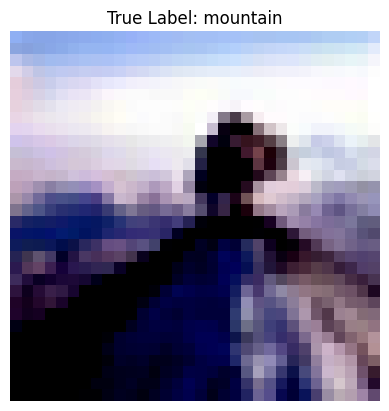

Predicted Label: castle


In [19]:
# Pick one image from the test dataset
image, label = test_dataset[0]  # Already a torch.Tensor of shape [C, H, W]
print(image.shape)
# Permute convert [C, H, W] → [H, W, C] for plotting)
plt.imshow(image.permute(1, 2, 0))
plt.title(f"True Label: {classes[label]}")
plt.axis('off')
plt.show()

# Prepare image for model input
image = image.unsqueeze(0).to(device)  # Add batch dim: [1, C, H, W]

# Make prediction
model.eval()
with torch.no_grad():
    output = model(image)                # Forward pass
    _, predicted = torch.max(output, 1)  # Get predicted class index

# Print predicted class
print(f"Predicted Label: {classes[predicted.item()]}")

### Dropout

In [33]:
class DenseANN_LinearOnly(nn.Module):
    def __init__(self):
        super(DenseANN_LinearOnly, self).__init__()
        self.flatten = nn.Flatten()

        self.fc1 = nn.Linear(32*32*3, 1024)
        self.ac1 = nn.ReLU()
        self.drop1 = nn.Dropout(p=0.2)  # Dropout after first activation

        self.fc2 = nn.Linear(1024, 512)
        self.ac2 = nn.ReLU()
        self.drop2 = nn.Dropout(p=0.2)  # Dropout after second activation

        self.fc3 = nn.Linear(512, 100)  # Output layer for 100 classes

    def forward(self, x):
        x = self.flatten(x)

        x = self.fc1(x)
        x = self.ac1(x)
        x = self.drop1(x)

        x = self.fc2(x)
        x = self.ac2(x)
        x = self.drop2(x)

        x = self.fc3(x)
        
        return x

# Instantiate and move to device
model1 = DenseANN_LinearOnly().to(device)


In [34]:
# 5. Loss and Optimizer with L2 Regularization
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model1.parameters(), lr=0.1)

In [35]:
# 6. Training loop with weight visualization

numEpoch = 10
for epoch in range(numEpoch):
    model1.train()
    total_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model1(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    print(f"\nEpoch [{epoch+1}/{numEpoch}] Loss: {total_loss:.4f} Accuracy: {correct/total*100:.2f}%")


# 7. Test accuracy
model1.eval()
correct = 0
total = 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model1(images)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

print(f"\nFinal Test Accuracy: {correct / total * 100:.2f}%")




Epoch [1/10] Loss: 5913.8083 Accuracy: 12.40%

Epoch [2/10] Loss: 5281.9266 Accuracy: 19.16%

Epoch [3/10] Loss: 4977.6336 Accuracy: 22.71%

Epoch [4/10] Loss: 4734.4089 Accuracy: 25.41%

Epoch [5/10] Loss: 4537.2535 Accuracy: 28.03%

Epoch [6/10] Loss: 4351.7265 Accuracy: 30.24%

Epoch [7/10] Loss: 4168.8588 Accuracy: 32.52%

Epoch [8/10] Loss: 3986.7367 Accuracy: 34.83%

Epoch [9/10] Loss: 3823.5126 Accuracy: 37.08%

Epoch [10/10] Loss: 3668.2690 Accuracy: 38.95%

Final Test Accuracy: 24.46%


### Learning Rate

In [24]:
class DenseANN_LinearOnly(nn.Module):
    def __init__(self):
        super(DenseANN_LinearOnly, self).__init__()
        self.flatten = nn.Flatten()

        self.fc1 = nn.Linear(32*32*3, 1024)
        self.ac1 = nn.ReLU()
        self.fc2 = nn.Linear(1024, 512)
        self.ac2 = nn.ReLU()
        self.fc3 = nn.Linear(512, 100)  # 100 classes for CIFAR-100

    def forward(self, x):
        x = self.flatten(x)

        x = self.fc1(x)
        x = self.ac1(x)
        x = self.fc2(x)
        x = self.ac2(x)
        x = self.fc3(x)
        
        return x

# Instantiate and send to device
model2 = DenseANN_LinearOnly().to(device)


In [25]:
# 5. Loss and Optimizer with L2 Regularization
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model2.parameters(), lr=0.001)

In [26]:
# 6. Training loop with weight visualization

numEpoch = 5
for epoch in range(numEpoch):
    model2.train()
    total_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model2(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    print(f"\nEpoch [{epoch+1}/{numEpoch}] Loss: {total_loss:.4f} Accuracy: {correct/total*100:.2f}%")


# 7. Test accuracy
model2.eval()
correct = 0
total = 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model2(images)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

print(f"\nFinal Test Accuracy: {correct / total * 100:.2f}%")




Epoch [1/5] Loss: 5550.8111 Accuracy: 16.48%

Epoch [2/5] Loss: 5416.3101 Accuracy: 18.08%

Epoch [3/5] Loss: 5355.7251 Accuracy: 18.79%

Epoch [4/5] Loss: 5314.3581 Accuracy: 19.37%

Epoch [5/5] Loss: 5280.8875 Accuracy: 19.79%

Final Test Accuracy: 18.57%


### Batch Normalization

In [39]:
import torch.nn as nn

class DenseANN_BatchNorm(nn.Module):
    def __init__(self):
        super(DenseANN_BatchNorm, self).__init__()
        self.flatten = nn.Flatten()

        self.fc1 = nn.Linear(32*32*3, 1024)
        self.bn1 = nn.BatchNorm1d(1024)
        self.ac1 = nn.ReLU()

        self.fc2 = nn.Linear(1024, 512)
        self.bn2 = nn.BatchNorm1d(512)
        self.ac2 = nn.ReLU()

        self.fc3 = nn.Linear(512, 100)  # 100 classes for CIFAR-100

    def forward(self, x):
        x = self.flatten(x)

        x = self.fc1(x)
        x = self.bn1(x)
        x = self.ac1(x)

        x = self.fc2(x)
        x = self.bn2(x)
        x = self.ac2(x)

        x = self.fc3(x)

        return x

# Instantiate and send to device
model3 = DenseANN_BatchNorm().to(device)


In [40]:
# 5. Loss and Optimizer with L2 Regularization
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model3.parameters(), lr=0.1)

In [41]:
# 6. Training loop with weight visualization

numEpoch = 10
for epoch in range(numEpoch):
    model3.train()
    total_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model3(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    print(f"\nEpoch [{epoch+1}/{numEpoch}] Loss: {total_loss:.4f} Accuracy: {correct/total*100:.2f}%")


# 7. Test accuracy
model3.eval()
correct = 0
total = 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model3(images)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

print(f"\nFinal Test Accuracy: {correct / total * 100:.2f}%")




Epoch [1/10] Loss: 5739.0945 Accuracy: 14.35%

Epoch [2/10] Loss: 5076.3038 Accuracy: 21.42%

Epoch [3/10] Loss: 4737.8422 Accuracy: 25.49%

Epoch [4/10] Loss: 4477.4767 Accuracy: 28.75%

Epoch [5/10] Loss: 4247.8743 Accuracy: 31.46%

Epoch [6/10] Loss: 4023.5799 Accuracy: 34.71%

Epoch [7/10] Loss: 3815.3725 Accuracy: 37.24%

Epoch [8/10] Loss: 3613.7384 Accuracy: 39.77%

Epoch [9/10] Loss: 3414.1772 Accuracy: 42.84%

Epoch [10/10] Loss: 3212.0396 Accuracy: 45.72%

Final Test Accuracy: 28.43%


### Adam Optimizer

In [44]:
# 4. Define a more dense ANN model
# 4. Define a more dense ANN model with Dropout
class DenseANN_LinearOnly(nn.Module):
    def __init__(self):
        super(DenseANN_LinearOnly, self).__init__()
        self.flatten = nn.Flatten()

        self.fc1 = nn.Linear(32*32*3, 1024)
        self.ac1 = nn.ReLU()
        self.fc2 = nn.Linear(1024, 512)
        self.ac2 = nn.ReLU()
        self.fc3 = nn.Linear(512, 100)  # 100 classes for CIFAR-100

    def forward(self, x):
        x = self.flatten(x)

        x = self.fc1(x)
        x = self.ac1(x)
        x = self.fc2(x)
        x = self.ac2(x)
        x = self.fc3(x)

        
        return x

# Instantiate and send to device
model4 = DenseANN_LinearOnly().to(device)


In [45]:
# 5. Loss and Optimizer with L2 Regularization
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model4.parameters(), lr=0.0005) #, weight_decay=1e-4

In [46]:
# 6. Training loop with weight visualization

numEpoch = 10
for epoch in range(numEpoch):
    model4.train()
    total_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model4(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    print(f"\nEpoch [{epoch+1}/{numEpoch}] Loss: {total_loss:.4f} Accuracy: {correct/total*100:.2f}%")


# 7. Test accuracy
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model4(images)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

print(f"\nFinal Test Accuracy: {correct / total * 100:.2f}%")




Epoch [1/10] Loss: 5785.4887 Accuracy: 13.96%

Epoch [2/10] Loss: 5151.4981 Accuracy: 20.74%

Epoch [3/10] Loss: 4802.5857 Accuracy: 24.89%

Epoch [4/10] Loss: 4492.4741 Accuracy: 28.57%

Epoch [5/10] Loss: 4210.4600 Accuracy: 32.01%

Epoch [6/10] Loss: 3920.6589 Accuracy: 35.80%

Epoch [7/10] Loss: 3633.1164 Accuracy: 39.38%

Epoch [8/10] Loss: 3343.4334 Accuracy: 43.63%

Epoch [9/10] Loss: 3056.0836 Accuracy: 47.77%

Epoch [10/10] Loss: 2773.4754 Accuracy: 51.90%

Final Test Accuracy: 25.11%
